# 🚌 ETA Prediction – Bus Transjakarta (1D LSTM, PyTorch)

**Target**: `eta_minutes` = selisih waktu antara `tapOutTime` dan `tapInTime`  
**Input features**: `corridorID`, `tapInStops`, `tapOutStops`, `hour`, `day_of_week`, `direction`, `stopStartSeq`, `stopEndSeq`, `bus_type`, `stop_dist`  
**Model**: 1D LSTM (PyTorch)  
**Encoding**: Frequency/target encoding — **no label encoder**  
**Augmentasi**: Synthetic data jika total rows < threshold


In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn -q
# torch sudah tersedia di Colab


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

torch.manual_seed(42)
np.random.seed(42)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
SEED = 42
print('Libraries loaded ✅')


Device: cuda
Libraries loaded ✅


## Config

In [11]:
BIG_BUS_CSV   = '../Dataset/bus_besar_all.csv'
SMALL_BUS_CSV = '../Dataset/bus_kecil_all.csv'

MIN_ROWS      = 50_000   # jika total data < ini, generate synthetic sampai cukup
SYNTH_RATIO   = 0.3      # synthetic = 30% dari target total jika kurang

SEQUENCE_LEN  = 8        # panjang sequence LSTM (trip berurutan per corridor)
HIDDEN_SIZE   = 64
NUM_LAYERS    = 2
DROPOUT       = 0.2
EPOCHS        = 60
BATCH_SIZE    = 512
LR            = 1e-3
PATIENCE      = 10

TEST_SIZE     = 0.2


---
## 1. Load & Merge Data

In [12]:
besar = pd.read_csv(BIG_BUS_CSV)
kecil = pd.read_csv(SMALL_BUS_CSV)

besar['bus_type'] = 'besar'
kecil['bus_type'] = 'kecil'

df = pd.concat([besar, kecil], ignore_index=True)
print(f'Total rows  : {len(df):,}')
print(f'Bus Besar   : {len(besar):,}')
print(f'Bus Kecil   : {len(kecil):,}')
df.head(3)


Total rows  : 182,520
Bus Besar   : 103,996
Bus Kecil   : 78,524


,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,...,stopStartSeq,tapInTime,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount,bus_type
0,VRPJ892P3M98RA,3561407960318444,dki,"Dr. Janet Nashiruddin, M.Ak",M,2010,4,Pulo Gadung 2 - Tosari,1.0,P00167,...,12,2023-04-03 06:53:02,P00127,Layur,-6.193539,106.89909,13.0,2023-04-03 07:13:28,3500.0,besar
1,YRLD835V6L82GO,377105453850671,emoney,Dian Mustofa,F,1993,B13,Bekasi Barat - Blok M,1.0,B02192P,...,6,2023-04-03 05:13:24,B00108P,Bandar Djakarta Bekasi,-6.227085,106.99683,9.0,2023-04-03 06:01:23,20000.0,besar
2,ZZBX143N6N83HQ,4486493302356581,dki,"Cut Janet Suryatmi, M.Ak",M,1980,8K,Batusari - Grogol,1.0,B03637P,...,16,2023-04-03 05:20:24,NaN,Yayasan Alkahfi Jakbar,-6.198896,106.76889,26.0,2023-04-03 06:01:25,3500.0,besar


---
## 2. Feature Engineering

In [13]:
df['tapInTime']  = pd.to_datetime(df['tapInTime'],  errors='coerce')
df['tapOutTime'] = pd.to_datetime(df['tapOutTime'], errors='coerce')

# Target
df['eta_minutes'] = (df['tapOutTime'] - df['tapInTime']).dt.total_seconds() / 60

# Time features
df['hour']        = df['tapInTime'].dt.hour
df['day_of_week'] = df['tapInTime'].dt.dayofweek
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
df['month']       = df['tapInTime'].dt.month

# Stop distance
df['stop_dist'] = (df['stopEndSeq'] - df['stopStartSeq']).abs()

# Rush hour proxy
df['is_rush'] = df['hour'].apply(lambda h: 1 if (7 <= h <= 9) or (17 <= h <= 19) else 0)

# Bus type binary (no label encoder)
df['bus_type_enc'] = (df['bus_type'] == 'besar').astype(int)

print('ETA stats (menit):')
print(df['eta_minutes'].describe().round(2))


ETA stats (menit):
count    176053.00
mean         72.15
std          28.14
min          15.00
25%          51.05
50%          71.77
75%          96.02
max         180.00
Name: eta_minutes, dtype: float64


In [14]:
before = len(df)
df = df.dropna(subset=['tapOutTime', 'tapInStops', 'tapOutStops', 'stopEndSeq', 'corridorID'])
df = df[df['eta_minutes'] > 0]
df = df[df['eta_minutes'] <= 180]
after = len(df)
print(f'Rows setelah cleaning: {after:,}  (dihapus {before-after:,})')


Rows setelah cleaning: 164,057  (dihapus 18,463)


---
## 3. EDA

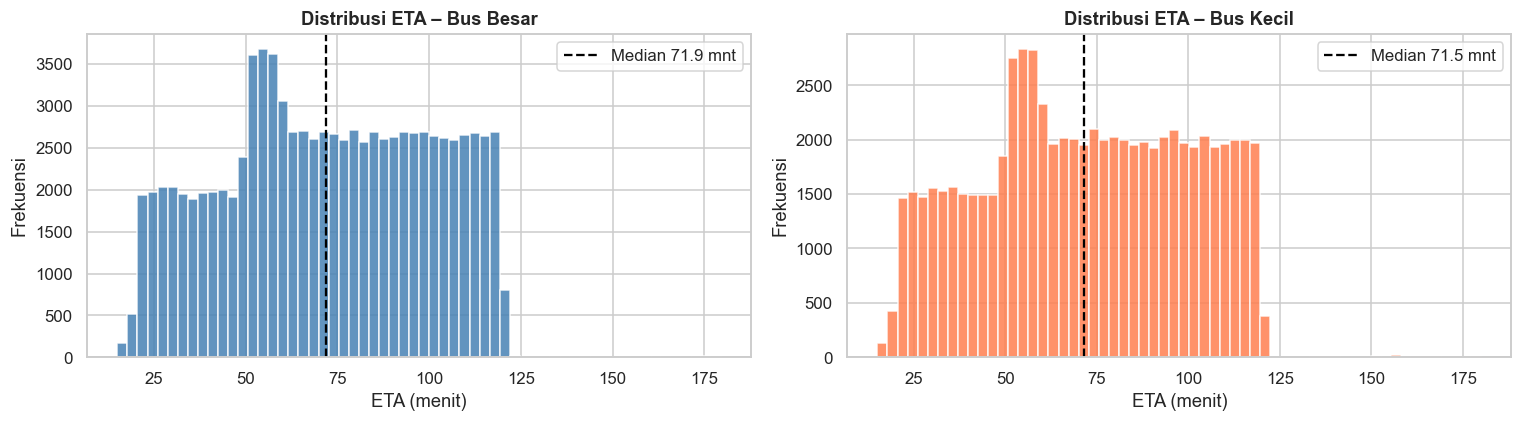

In [15]:
# 3.1 Distribusi ETA
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, btype, color in zip(axes, ['besar', 'kecil'], ['steelblue', 'coral']):
    subset = df[df['bus_type'] == btype]['eta_minutes']
    ax.hist(subset, bins=60, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribusi ETA – Bus {btype.capitalize()}', fontweight='bold')
    ax.set_xlabel('ETA (menit)')
    ax.set_ylabel('Frekuensi')
    ax.axvline(subset.median(), color='black', ls='--', label=f'Median {subset.median():.1f} mnt')
    ax.legend()
plt.tight_layout()
plt.show()


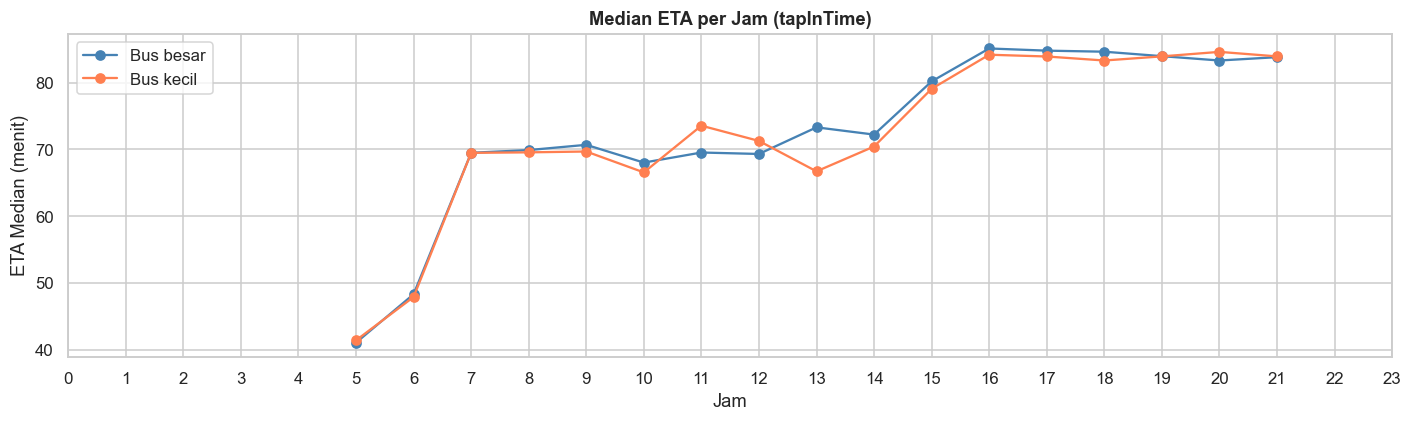

In [16]:
# 3.2 ETA per jam
fig, ax = plt.subplots(figsize=(13, 4))
for btype, color in [('besar', 'steelblue'), ('kecil', 'coral')]:
    sub = df[df['bus_type'] == btype].groupby('hour')['eta_minutes'].median()
    ax.plot(sub.index, sub.values, marker='o', label=f'Bus {btype}', color=color)
ax.set_title('Median ETA per Jam (tapInTime)', fontweight='bold')
ax.set_xlabel('Jam')
ax.set_ylabel('ETA Median (menit)')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()


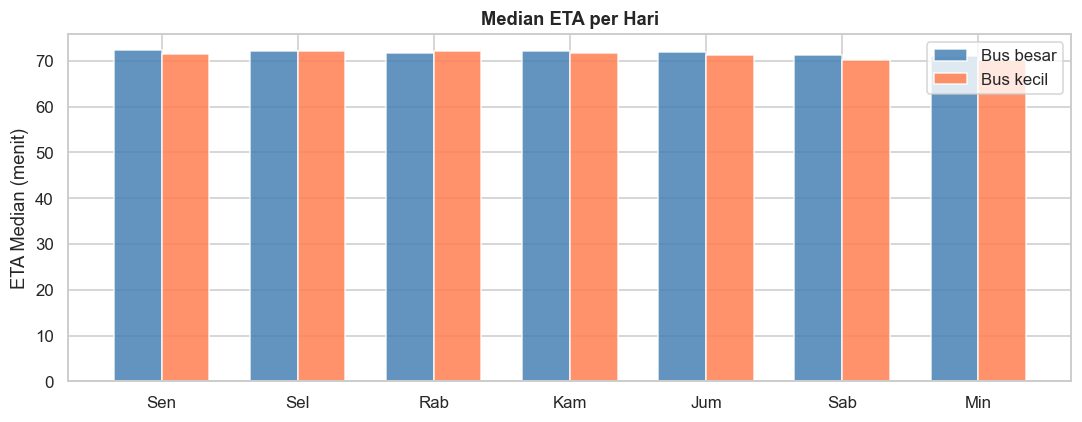

In [17]:
# 3.3 ETA per hari
day_labels = ['Sen','Sel','Rab','Kam','Jum','Sab','Min']
fig, ax = plt.subplots(figsize=(10, 4))
for btype, color in [('besar', 'steelblue'), ('kecil', 'coral')]:
    sub = df[df['bus_type'] == btype].groupby('day_of_week')['eta_minutes'].median()
    ax.bar(sub.index + (0 if btype == 'besar' else 0.35),
           sub.values, width=0.35, label=f'Bus {btype}', color=color, alpha=0.85)
ax.set_xticks([i + 0.175 for i in range(7)])
ax.set_xticklabels(day_labels)
ax.set_title('Median ETA per Hari', fontweight='bold')
ax.set_ylabel('ETA Median (menit)')
ax.legend()
plt.tight_layout()
plt.show()


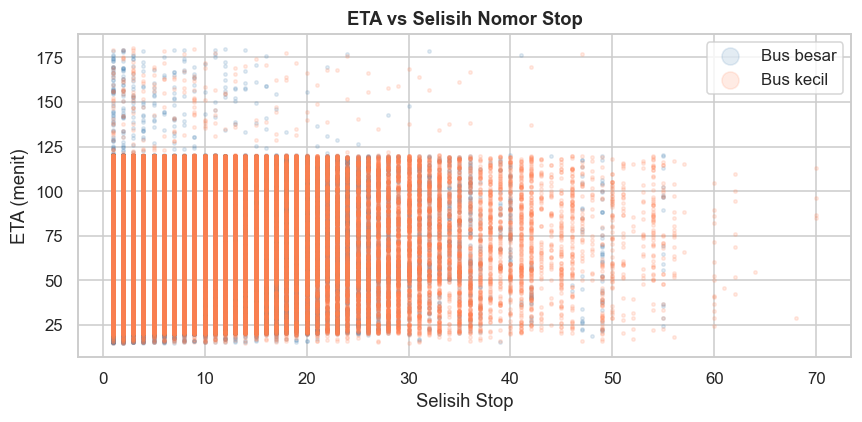

In [18]:
# 3.4 ETA vs stop_dist
fig, ax = plt.subplots(figsize=(8, 4))
for btype, color in [('besar', 'steelblue'), ('kecil', 'coral')]:
    sub = df[df['bus_type'] == btype]
    ax.scatter(sub['stop_dist'], sub['eta_minutes'],
               alpha=0.15, s=5, color=color, label=f'Bus {btype}')
ax.set_title('ETA vs Selisih Nomor Stop', fontweight='bold')
ax.set_xlabel('Selisih Stop')
ax.set_ylabel('ETA (menit)')
ax.legend(markerscale=5)
plt.tight_layout()
plt.show()


In [19]:
# 3.5 Top-10 corridor by volume
top10 = df.groupby('corridorID')['eta_minutes'].agg(['count','median']) \
          .sort_values('count', ascending=False).head(10)
print(top10.rename(columns={'count':'jumlah_transaksi','median':'eta_median_mnt'}).round(1))


            jumlah_transaksi  eta_median_mnt
corridorID                                  
12H                     1143            72.1
11                      1107            76.0
13                      1089            68.0
JAK.39                  1041            67.0
5                       1039            71.2
7                       1032            72.7
2B                      1031            76.6
S31                     1028            74.3
1N                      1017            72.9
11C                     1016            74.3


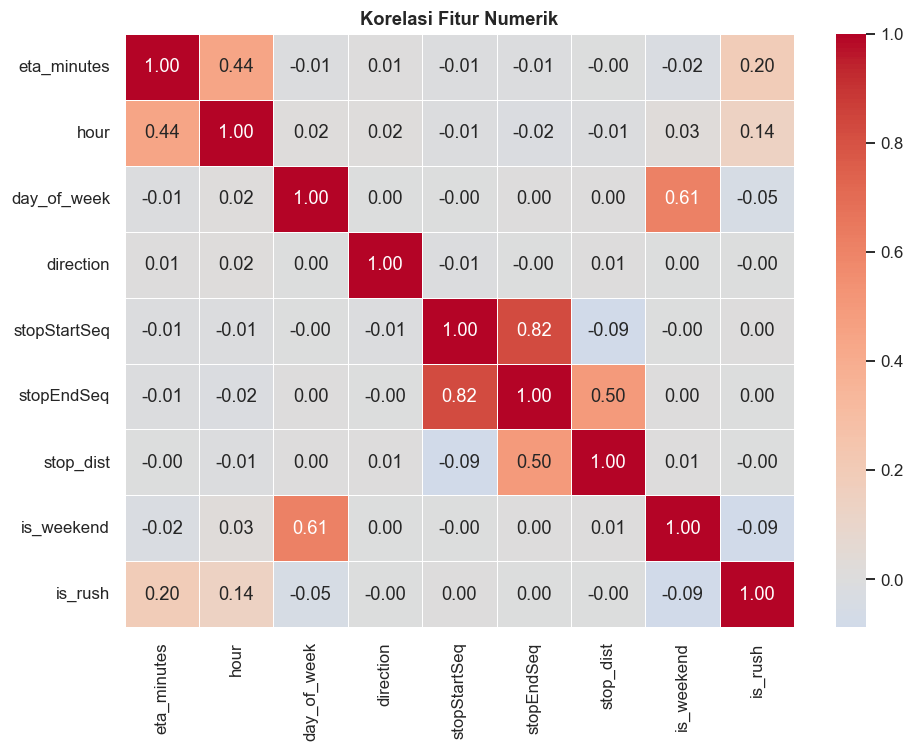

In [20]:
# 3.6 Korelasi numerik
num_cols = ['eta_minutes','hour','day_of_week','direction','stopStartSeq',
            'stopEndSeq','stop_dist','is_weekend','is_rush']
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, linewidths=0.5)
ax.set_title('Korelasi Fitur Numerik', fontweight='bold')
plt.tight_layout()
plt.show()


---
## 4. Encoding — No Label Encoder

- `corridorID` → **frequency encoding** (jumlah trip per corridor dari seluruh data)
- `tapInStops` / `tapOutStops` → **frequency encoding** (jumlah kemunculan)
- `bus_type` → binary (sudah di step 2)
- Semua numerik as-is


In [21]:
# Frequency encoding — dihitung dari keseluruhan data, bukan test set
# (untuk LSTM ini tidak ada train/test split dulu, encoding dihitung global
#  karena kita tidak predict future dates, melainkan trip ETA regression)
corridor_freq  = df['corridorID'].map(df['corridorID'].value_counts())
tapin_freq     = df['tapInStops'].map(df['tapInStops'].value_counts())
tapout_freq    = df['tapOutStops'].map(df['tapOutStops'].value_counts())

df['corridor_freq'] = corridor_freq
df['tapin_freq']    = tapin_freq
df['tapout_freq']   = tapout_freq

FEATURE_COLS = [
    'corridor_freq', 'tapin_freq', 'tapout_freq',
    'hour', 'day_of_week', 'is_weekend', 'is_rush', 'month',
    'direction', 'stopStartSeq', 'stopEndSeq', 'stop_dist',
    'bus_type_enc',
]
TARGET = 'eta_minutes'

model_df = df[FEATURE_COLS + [TARGET, 'corridorID']].dropna().copy()
print(f'Dataset siap: {model_df.shape}')
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')


Dataset siap: (164057, 15)
Features (13): ['corridor_freq', 'tapin_freq', 'tapout_freq', 'hour', 'day_of_week', 'is_weekend', 'is_rush', 'month', 'direction', 'stopStartSeq', 'stopEndSeq', 'stop_dist', 'bus_type_enc']


---
## 5. Synthetic Data Augmentation

Jika total rows < `MIN_ROWS`, generate synthetic samples dengan:
- Sample corridor, stop, arah dari distribusi existing
- Tambah Gaussian noise pada fitur numerik (std = 5–10% dari range)
- ETA synthetic dihitung dari hubungan linear `stop_dist × time_of_day_factor` + noise


In [22]:
def generate_synthetic(df_real: pd.DataFrame, n_synth: int) -> pd.DataFrame:
    """
    Generate synthetic ETA samples berdasarkan distribusi data asli.
    Tidak menggunakan data masa depan — noise ditambahkan ke statistik historis.
    """
    rng = np.random.default_rng(SEED)

    # Sample corridor + stop pairs dari data asli (preserve relasi corridor-stop)
    base = df_real[['corridorID','tapInStops','tapOutStops',
                    'direction','stopStartSeq','stopEndSeq',
                    'bus_type','bus_type_enc']].sample(n=n_synth, replace=True,
                                                        random_state=SEED).reset_index(drop=True)

    # Random time features
    base['hour']        = rng.integers(5, 24, n_synth)
    base['day_of_week'] = rng.integers(0,  7, n_synth)
    base['is_weekend']  = (base['day_of_week'] >= 5).astype(int)
    base['month']       = rng.integers(1, 13, n_synth)
    base['is_rush']     = base['hour'].apply(lambda h: 1 if (7<=h<=9) or (17<=h<=19) else 0)

    # Frequency encoding (dari df_real)
    corr_freq  = df_real['corridorID'].value_counts().to_dict()
    tapin_freq = df_real['tapInStops'].value_counts().to_dict()
    tapout_freq= df_real['tapOutStops'].value_counts().to_dict()
    global_mean= df_real['corridor_freq'].mean()

    base['corridor_freq'] = base['corridorID'].map(corr_freq).fillna(global_mean)
    base['tapin_freq']    = base['tapInStops'].map(tapin_freq).fillna(1)
    base['tapout_freq']   = base['tapOutStops'].map(tapout_freq).fillna(1)
    base['stop_dist']     = (base['stopEndSeq'] - base['stopStartSeq']).abs()

    # Generate ETA synthetic:
    # Base ETA = stop_dist × minutes_per_stop (pakai median dari data asli per corridor)
    corridor_eta_rate = (
        df_real.groupby('corridorID')
        .apply(lambda g: (g['eta_minutes'] / g['stop_dist'].clip(lower=1)).median())
        .to_dict()
    )
    global_rate = df_real['eta_minutes'].median() / df_real['stop_dist'].clip(lower=1).median()

    rate = base['corridorID'].map(corridor_eta_rate).fillna(global_rate).values
    rush_factor = np.where(base['is_rush'] == 1, 1.25, 1.0)
    weekend_factor = np.where(base['is_weekend'] == 1, 0.85, 1.0)

    eta_base  = base['stop_dist'].clip(lower=1).values * rate * rush_factor * weekend_factor
    eta_noise = rng.normal(0, eta_base * 0.12)        # ±12% Gaussian noise
    base['eta_minutes'] = np.clip(eta_base + eta_noise, 1, 180)

    base['__synthetic__'] = True
    return base


n_real = len(model_df)
print(f'Real data: {n_real:,} rows')

if n_real < MIN_ROWS:
    n_synth = int(MIN_ROWS * SYNTH_RATIO)
    print(f'Data kurang dari {MIN_ROWS:,} → generate {n_synth:,} synthetic rows...')
    synth = generate_synthetic(df, n_synth)
    synth_feat = synth[FEATURE_COLS + [TARGET, 'corridorID']].dropna()
    model_df['__synthetic__'] = False
    model_df = pd.concat([model_df, synth_feat], ignore_index=True)
    print(f'Total setelah augmentasi: {len(model_df):,} rows  '
          f'(real: {n_real:,}, synthetic: {len(synth_feat):,})')
else:
    model_df['__synthetic__'] = False
    print(f'Data cukup — tidak perlu augmentasi.')


Real data: 164,057 rows
Data cukup — tidak perlu augmentasi.


---
## 6. Scale & Train/Test Split

- Split **chronological**: shuffle=False, test = 20% terakhir
- `MinMaxScaler` fit pada train only
- Target juga di-scale ke [0, 1] untuk training, di-inverse setelah prediksi


In [23]:
# Chronological split — tidak shuffle
model_df = model_df.reset_index(drop=True)
split_idx = int(len(model_df) * (1 - TEST_SIZE))

train_df = model_df.iloc[:split_idx].copy()
test_df  = model_df.iloc[split_idx:].copy()

print(f'Train: {len(train_df):,} | Test: {len(test_df):,}')

# Scale features — fit pada train
feat_scaler = MinMaxScaler()
feat_scaler.fit(train_df[FEATURE_COLS])

X_train = feat_scaler.transform(train_df[FEATURE_COLS]).astype(np.float32)
X_test  = feat_scaler.transform(test_df[FEATURE_COLS]).astype(np.float32)

# Scale target — fit pada train
target_scaler = MinMaxScaler()
target_scaler.fit(train_df[[TARGET]])

y_train = target_scaler.transform(train_df[[TARGET]]).ravel().astype(np.float32)
y_test  = target_scaler.transform(test_df[[TARGET]]).ravel().astype(np.float32)

print(f'X_train: {X_train.shape}  X_test: {X_test.shape}')


Train: 131,245 | Test: 32,812
X_train: (131245, 13)  X_test: (32812, 13)


---
## 7. LSTM Sequence Dataset

Setiap sample = window `SEQUENCE_LEN` trip berurutan per corridor.  
`X` shape: `(n_samples, SEQUENCE_LEN, n_features)`  
`y` shape: `(n_samples,)` — ETA trip ke-`SEQUENCE_LEN+1`


In [24]:
def make_sequences_df(X: np.ndarray, y: np.ndarray,
                      corridor_ids: np.ndarray, seq_len: int):
    """
    Sliding window per corridor — hanya buat sequence dari trip dalam corridor yang sama.
    Ini memastikan LSTM belajar temporal pattern per rute, bukan lintas rute.
    """
    X_seq, y_seq = [], []
    unique_corridors = np.unique(corridor_ids)

    for corr in unique_corridors:
        mask   = corridor_ids == corr
        X_corr = X[mask]
        y_corr = y[mask]
        n      = len(X_corr)
        for i in range(seq_len, n):
            X_seq.append(X_corr[i - seq_len : i])   # (seq_len, n_feat)
            y_seq.append(y_corr[i])                  # scalar

    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32)


print('Building train sequences...')
X_tr_seq, y_tr_seq = make_sequences_df(
    X_train, y_train,
    train_df['corridorID'].values, SEQUENCE_LEN
)

print('Building test sequences...')
X_te_seq, y_te_seq = make_sequences_df(
    X_test, y_test,
    test_df['corridorID'].values, SEQUENCE_LEN
)

print(f'Train sequences: {X_tr_seq.shape}  |  Test sequences: {X_te_seq.shape}')


Building train sequences...
Building test sequences...
Train sequences: (129477, 8, 13)  |  Test sequences: (32044, 8, 13)


In [25]:
class ETADataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_loader = DataLoader(ETADataset(X_tr_seq, y_tr_seq),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(ETADataset(X_te_seq, y_te_seq),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')


Train batches: 253 | Test batches: 63


---
## 8. 1D LSTM Model (PyTorch)

```
Input  (batch, SEQUENCE_LEN, n_features)
  → LSTM(hidden=64, layers=2, dropout=0.2)
  → Linear(64 → 1)
Output (batch, 1) → inverse scale → ETA menit
```


In [26]:
class ETALSTM(nn.Module):
    def __init__(self, n_features: int, hidden_size: int = HIDDEN_SIZE,
                 num_layers: int = NUM_LAYERS, dropout: float = DROPOUT):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = n_features,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout if num_layers > 1 else 0.0,
            batch_first = True,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)       # (batch, seq, hidden)
        out     = out[:, -1, :]     # last timestep
        return self.fc(out).squeeze(-1)


model = ETALSTM(n_features=len(FEATURE_COLS)).to(DEVICE)
print(model)
print(f'\nTotal params: {sum(p.numel() for p in model.parameters()):,}')


ETALSTM(
  (lstm): LSTM(13, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Total params: 53,569


## 9. Training Loop

In [27]:
criterion = nn.HuberLoss()          # robust terhadap outlier ETA
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True
)

best_val_loss  = float('inf')
patience_count = 0
best_state     = None
history        = {'train_loss': [], 'val_loss': []}

for epoch in range(1, EPOCHS + 1):
    # ── Train
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * len(X_batch)
    train_loss /= len(train_loader.dataset)

    # ── Validate
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            pred      = model(X_batch)
            val_loss += criterion(pred, y_batch).item() * len(X_batch)
    val_loss /= len(test_loader.dataset)

    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | train: {train_loss:.4f} | val: {val_loss:.4f}')

    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        patience_count = 0
        best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

model.load_state_dict(best_state)
print('Training selesai ✅')


Epoch   1 | train: 0.0144 | val: 0.0146
Epoch  10 | train: 0.0115 | val: 0.0138
Epoch  20 | train: 0.0113 | val: 0.0136
Epoch  30 | train: 0.0112 | val: 0.0135
Epoch  40 | train: 0.0112 | val: 0.0135
Epoch  50 | train: 0.0111 | val: 0.0135
Epoch  60 | train: 0.0111 | val: 0.0135
Early stopping at epoch 60
Training selesai ✅


---
## 10. Evaluasi

In [28]:
model.eval()
y_pred_scaled = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        y_pred_scaled.append(model(X_batch.to(DEVICE)).cpu().numpy())
y_pred_scaled = np.concatenate(y_pred_scaled)

# Inverse scale
y_pred_min = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_true_min = target_scaler.inverse_transform(y_te_seq.reshape(-1, 1)).ravel()

# Clip negatif (edge case)
y_pred_min = np.clip(y_pred_min, 0, 180)

mae  = mean_absolute_error(y_true_min, y_pred_min)
rmse = mean_squared_error(y_true_min, y_pred_min) ** 0.5
r2   = r2_score(y_true_min, y_pred_min)
mape = np.mean(np.abs((y_true_min - y_pred_min) / np.clip(y_true_min, 1, None))) * 100

print('='*40)
print(f'  MAE  : {mae:.2f} menit')
print(f'  RMSE : {rmse:.2f} menit')
print(f'  MAPE : {mape:.1f}%')
print(f'  R²   : {r2:.4f}')
print('='*40)


  MAE  : 22.73 menit
  RMSE : 27.01 menit
  MAPE : 41.5%
  R²   : 0.0437


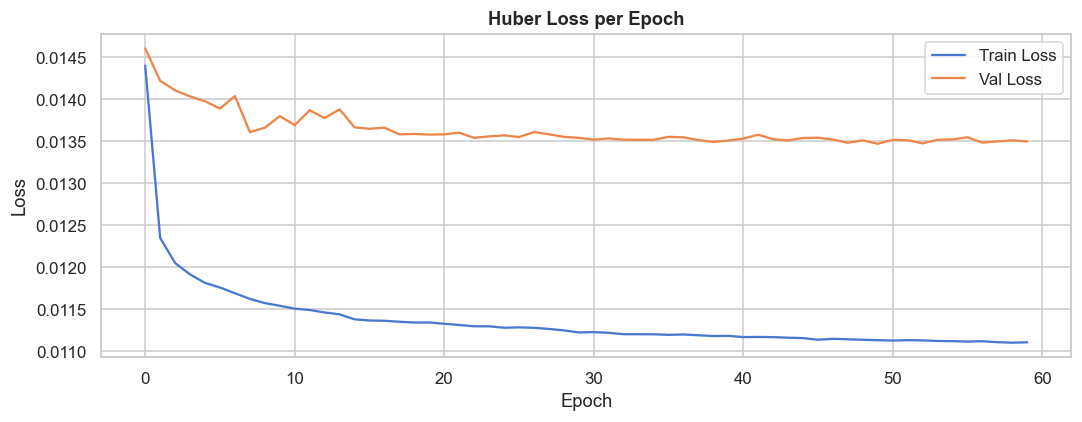

In [29]:
# Loss curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train_loss'], label='Train Loss')
ax.plot(history['val_loss'],   label='Val Loss')
ax.set_title('Huber Loss per Epoch', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()


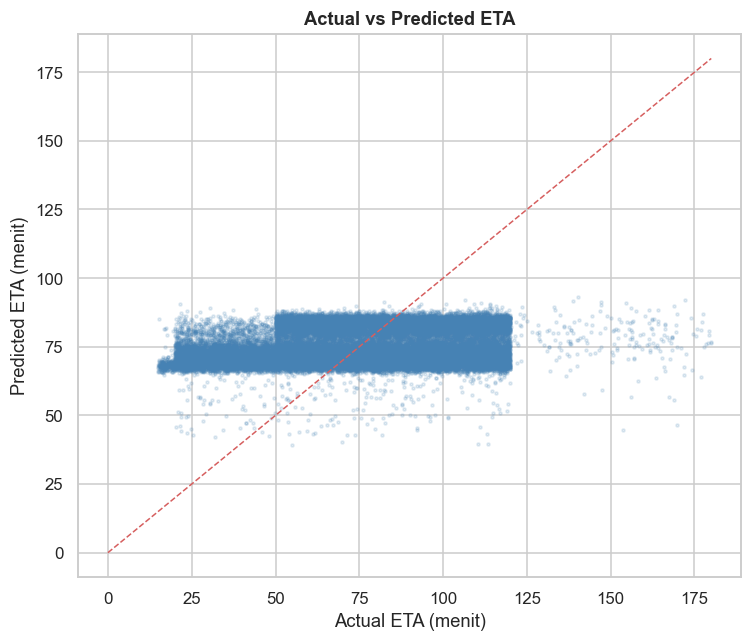

In [30]:
# Actual vs Predicted scatter
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_true_min, y_pred_min, alpha=0.15, s=4, color='steelblue')
lims = [0, max(y_true_min.max(), y_pred_min.max())]
ax.plot(lims, lims, 'r--', lw=1)
ax.set_title('Actual vs Predicted ETA', fontweight='bold')
ax.set_xlabel('Actual ETA (menit)')
ax.set_ylabel('Predicted ETA (menit)')
plt.tight_layout()
plt.show()


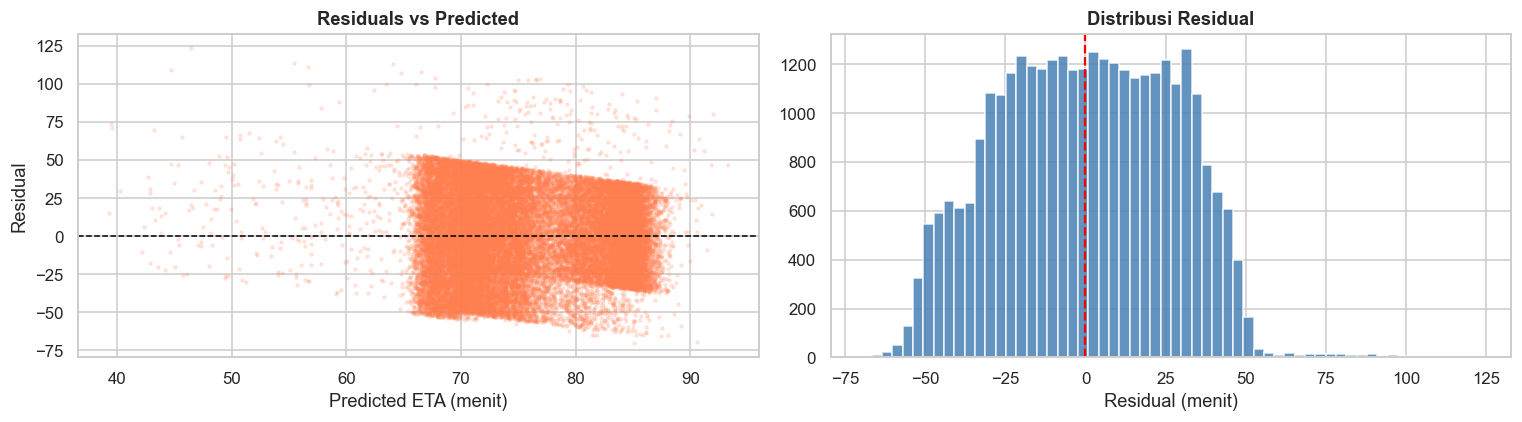

In [31]:
# Residual plot
residuals = y_true_min - y_pred_min
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(y_pred_min, residuals, alpha=0.15, s=4, color='coral')
axes[0].axhline(0, color='black', lw=1, ls='--')
axes[0].set_title('Residuals vs Predicted', fontweight='bold')
axes[0].set_xlabel('Predicted ETA (menit)')
axes[0].set_ylabel('Residual')

axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', ls='--')
axes[1].set_title('Distribusi Residual', fontweight='bold')
axes[1].set_xlabel('Residual (menit)')

plt.tight_layout()
plt.show()


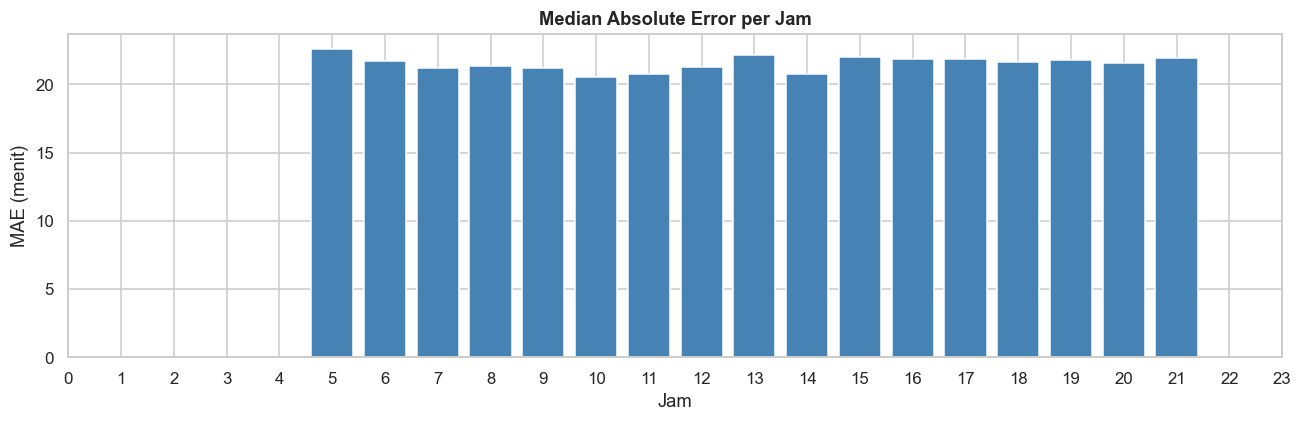

In [32]:
# Error per jam — apakah LSTM lebih salah di jam tertentu?
test_df_eval = test_df.iloc[SEQUENCE_LEN:].copy().reset_index(drop=True)
# pastikan panjangnya sama dengan prediksi (karena sequence build per-corridor,
# panjangnya bisa berbeda — kita pakai sample y_true_min saja untuk hour analysis)
n_eval = min(len(y_true_min), len(test_df_eval))
test_df_eval = test_df_eval.iloc[:n_eval].copy()
test_df_eval['y_pred'] = y_pred_min[:n_eval]
test_df_eval['y_true'] = y_true_min[:n_eval]
test_df_eval['abs_err'] = np.abs(test_df_eval['y_true'] - test_df_eval['y_pred'])

hour_err = test_df_eval.groupby('hour')['abs_err'].median()
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hour_err.index, hour_err.values, color='steelblue', edgecolor='white')
ax.set_title('Median Absolute Error per Jam', fontweight='bold')
ax.set_xlabel('Jam')
ax.set_ylabel('MAE (menit)')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()


---
## 11. Prediksi ETA pada Data Baru

Input: sekuens `SEQUENCE_LEN` trip terakhir dari corridor yang sama.


In [ ]:
def predict_eta_lstm(trips: list[dict]) -> float:
    """
    Prediksi ETA trip berikutnya berdasarkan SEQUENCE_LEN trip terakhir.

    Setiap dict dalam `trips` harus punya key:
        corridorID, tapInStops, tapOutStops, hour, day_of_week,
        direction, stopStartSeq, stopEndSeq, bus_type ('besar'/'kecil')

    Return: prediksi ETA dalam menit (float)
    """
    assert len(trips) == SEQUENCE_LEN, f'Perlu tepat {SEQUENCE_LEN} trips sebagai input'

    rows = []
    for t in trips:
        stop_dist = abs(t['stopEndSeq'] - t['stopStartSeq'])
        is_weekend = 1 if t['day_of_week'] >= 5 else 0
        is_rush    = 1 if (7 <= t['hour'] <= 9) or (17 <= t['hour'] <= 19) else 0
        month      = t.get('month', 4)

        # Frequency encoding dari data training
        corr_f  = df['corridorID'].value_counts().get(t['corridorID'], 1)
        tapin_f = df['tapInStops'].value_counts().get(t['tapInStops'], 1)
        tapout_f= df['tapOutStops'].value_counts().get(t['tapOutStops'], 1)

        rows.append({
            'corridor_freq' : corr_f,
            'tapin_freq'    : tapin_f,
            'tapout_freq'   : tapout_f,
            'hour'          : t['hour'],
            'day_of_week'   : t['day_of_week'],
            'is_weekend'    : is_weekend,
            'is_rush'       : is_rush,
            'month'         : month,
            'direction'     : t['direction'],
            'stopStartSeq'  : t['stopStartSeq'],
            'stopEndSeq'    : t['stopEndSeq'],
            'stop_dist'     : stop_dist,
            'bus_type_enc'  : 1 if t['bus_type'] == 'besar' else 0,
        })

    feat_df = pd.DataFrame(rows)[FEATURE_COLS]
    scaled  = feat_scaler.transform(feat_df).astype(np.float32)
    tensor  = torch.tensor(scaled[np.newaxis], dtype=torch.float32).to(DEVICE)

    model.eval()
    with torch.no_grad():
        pred_scaled = model(tensor).cpu().item()

    eta = target_scaler.inverse_transform([[pred_scaled]])[0][0]
    return round(float(np.clip(eta, 0, 180)), 1)


In [ ]:
# ── Contoh prediksi: ambil 8 trip berurutan dari corridor yang sama
sample_corr = df['corridorID'].value_counts().index[0]  # corridor paling ramai
sample_trips = (
    df[df['corridorID'] == sample_corr]
    .dropna(subset=FEATURE_COLS)
    .head(SEQUENCE_LEN)
    .to_dict(orient='records')
)

trips_input = []
for row in sample_trips:
    trips_input.append({
        'corridorID'  : row['corridorID'],
        'tapInStops'  : row.get('tapInStops', ''),
        'tapOutStops' : row.get('tapOutStops', ''),
        'hour'        : int(row['hour']),
        'day_of_week' : int(row['day_of_week']),
        'direction'   : int(row.get('direction', 1)),
        'stopStartSeq': int(row.get('stopStartSeq', 1)),
        'stopEndSeq'  : int(row.get('stopEndSeq', 5)),
        'bus_type'    : row.get('bus_type', 'besar'),
        'month'       : int(row.get('month', 4)),
    })

eta_pred = predict_eta_lstm(trips_input)
print(f'Prediksi ETA trip berikutnya : {eta_pred} menit')
print(f'Corridor                     : {sample_corr}')
print(f'Jam input terakhir           : {trips_input[-1]["hour"]:02d}:00')
print(f'Hari input terakhir          : {trips_input[-1]["day_of_week"]} (0=Sen)')


---
## 12. Summary

| Komponen | Detail |
|----------|--------|
| Model | 1D LSTM (PyTorch) — 2 layers, hidden=64, dropout=0.2 |
| Input | Sequence 8 trip berurutan per corridor |
| Encoding | Frequency encoding (no label encoder) |
| Loss | Huber Loss (robust outlier) |
| Optimizer | Adam + ReduceLROnPlateau |
| Augmentasi | Synthetic data jika rows < 50k (noise berbasis distribusi asli) |
| Split | Chronological 80/20 — no shuffle |
| Output | Prediksi ETA dalam menit |
